# SMD Anomaly Detection: LSTM Autoencoder vs. TiReX

## Part 0: Introduction

This notebook compares two unsupervised anomaly detection methods on the Server Machine Dataset (SMD):

1. an LSTM autoencoder trained on normal data;
2. the pretrained TiReX forecasting model used zero-shot, without fine-tuning.

Test labels are used only for label-aware dataset inspection and final evaluation. They are not used for preprocessing, model fitting, residual scaling, anomaly score construction, or threshold selection.

## Notebook outline

1. Set up the experiment.
2. Load and explore SMD machine-1-1.
3. Split and standardize the normal training sequence.
4. Train an LSTM autoencoder and calculate reconstruction residuals.
5. Run TiReX zero-shot and calculate forecast residuals.
6. Convert both residual matrices into anomaly scores.
7. Evaluate both methods on a shared set of test timestamps.
8. Save the model, scores, metrics, and figures.

Prerequisites: Python, NumPy, pandas, matplotlib, scikit-learn, PyTorch, and tirex-ts 1.4.2.

## Part 1: Setup

All important experiment settings are kept together below. Fixing the random seed makes the training part easier to reproduce.

In [ ]:
from pathlib import Path
from copy import deepcopy
import json
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2

In [ ]:
MACHINE = "machine-1-1"
TRAIN_FRACTION = 0.70
CALIBRATION_FRACTION = 0.15

AE_WINDOW = 64
AE_HIDDEN = 64
AE_LATENT = 16
AE_BATCH_SIZE = 128
AE_LEARNING_RATE = 1e-3
AE_EPOCHS = 30
AE_PATIENCE = 5

TIREX_CONTEXT = 96
TIREX_HORIZON = 96
TIREX_STRIDE = 96
TIREX_BATCH_SIZE = 512

TOP_K = 5
THRESHOLD_QUANTILE = 0.995

AE_DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
TIREX_DEVICE = "cpu"

print("Autoencoder device:", AE_DEVICE)
print("TiReX device:", TIREX_DEVICE)

Autoencoder device: mps
TiReX device: cpu


## Part 2: Load and Explore SMD

machine-1-1 is a multivariate server time series with 38 channels. The official training sequence contains normal observations. The test sequence contains both normal and anomalous timestamps.

This section uses the provided test labels only for a small diagnostic summary and visualization. The labels are not used to fit either detector or choose thresholds.

In [ ]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

candidate_data_roots = [
    PROJECT_ROOT.parent / "data" / "SMD",
    PROJECT_ROOT / "data" / "SMD",
]
DATA_ROOT = next(
    (path for path in candidate_data_roots if path.exists()),
    candidate_data_roots[0],
)
OUTPUT_DIR = PROJECT_ROOT / "results" / "notebook_complete"

train_path = DATA_ROOT / "train" / f"{MACHINE}.txt"
test_path = DATA_ROOT / "test" / f"{MACHINE}.txt"
label_path = DATA_ROOT / "test_label" / f"{MACHINE}.txt"

for path in [train_path, test_path, label_path]:
    if not path.exists():
        raise FileNotFoundError(f"Required SMD file not found: {path}")

train_data = np.loadtxt(train_path, delimiter=",").astype(np.float64)
test_data = np.loadtxt(test_path, delimiter=",").astype(np.float64)
test_labels = np.loadtxt(label_path, delimiter=",").astype(np.int64).reshape(-1)

assert train_data.ndim == 2
assert test_data.ndim == 2
assert train_data.shape[1] == test_data.shape[1]
assert len(test_data) == len(test_labels)
assert np.isin(test_labels, [0, 1]).all()

In [ ]:
print("Training shape:", train_data.shape)
print("Test shape:    ", test_data.shape)
print("Channels:      ", train_data.shape[1])
print("Test anomalies:", int(test_labels.sum()))
print("Anomaly rate:  ", f"{test_labels.mean():.2%}")

Training shape: (28479, 38)
Test shape:     (28479, 38)
Channels:       38
Test anomalies: 2694
Anomaly rate:   9.46%


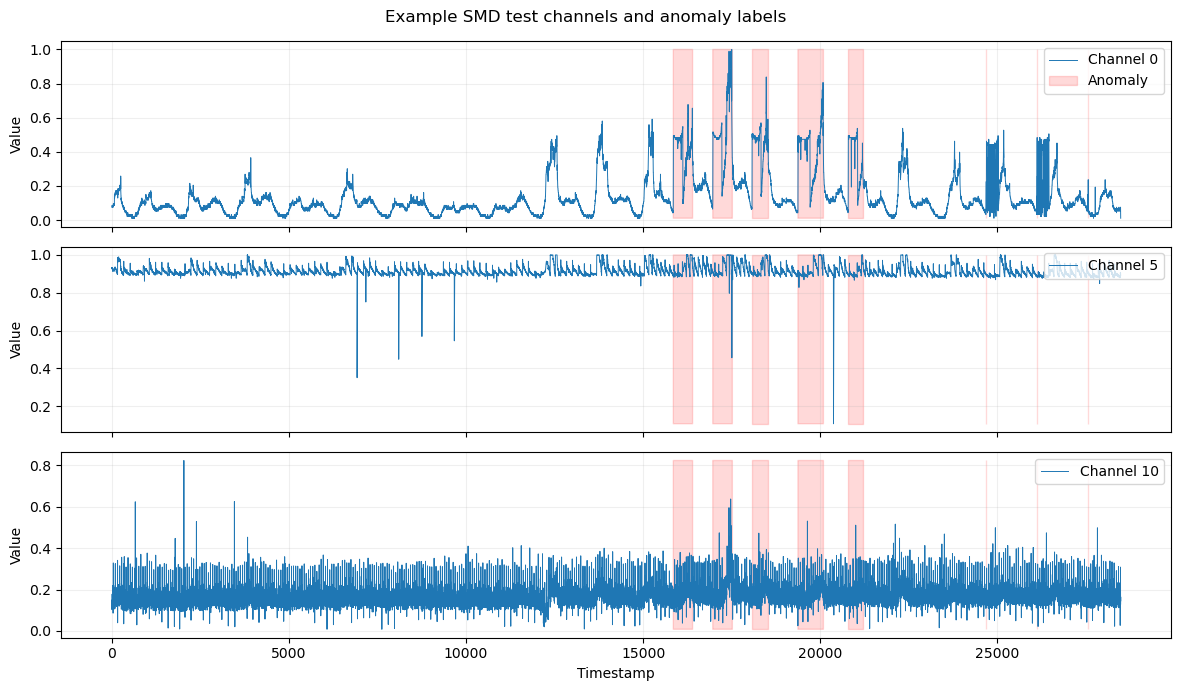

In [ ]:
channels_to_plot = [0, 5, 10]
fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(12, 7), sharex=True)

for channel, axis in zip(channels_to_plot, axes):
    values = test_data[:, channel]
    axis.plot(values, linewidth=0.7, label=f"Channel {channel}")
    axis.fill_between(
        np.arange(len(values)),
        values.min(),
        values.max(),
        where=test_labels.astype(bool),
        color="red",
        alpha=0.15,
        label="Anomaly" if channel == channels_to_plot[0] else None,
    )
    axis.set_ylabel("Value")
    axis.legend(loc="upper right")

axes[-1].set_xlabel("Timestamp")
fig.suptitle("Example SMD test channels and anomaly labels")
fig.tight_layout()
plt.show()

## Part 3: Prepare the Data

The normal training sequence is split chronologically:

- the first 70% fits the standardizer and autoencoder;
- the next 15% validates the autoencoder and calibrates residual scales;
- the final 15% selects an unsupervised anomaly threshold.

The standardizer is fitted only on the first split. The calibration split is used both as the autoencoder validation split for early stopping and to estimate robust channel-wise residual scales. The separate threshold split is then used only to select the anomaly threshold. This prevents later normal timestamps or test labels from leaking into preprocessing, model fitting, residual scaling, or threshold selection.

In [ ]:
fit_end = int(len(train_data) * TRAIN_FRACTION)
calibration_end = int(
    len(train_data) * (TRAIN_FRACTION + CALIBRATION_FRACTION)
)
fit_slice = slice(0, fit_end)
calibration_slice = slice(fit_end, calibration_end)
threshold_slice = slice(calibration_end, len(train_data))

feature_mean = train_data[fit_slice].mean(axis=0)
feature_std = train_data[fit_slice].std(axis=0)
feature_std = np.where(feature_std > 0, feature_std, 1.0)
train_scaled = (train_data - feature_mean) / feature_std
test_scaled = (test_data - feature_mean) / feature_std

print("Fit timestamps:        ", fit_end)
print("Calibration timestamps:", calibration_end - fit_end)
print("Threshold timestamps:  ", len(train_data) - calibration_end)
print(
    "Largest fitted mean after scaling:",
    f"{np.abs(train_scaled[fit_slice].mean(axis=0)).max():.3e}",
)

Fit timestamps:         19935
Calibration timestamps: 4272
Threshold timestamps:   4272
Largest fitted mean after scaling: 4.137e-13


## Part 4: LSTM Autoencoder

The autoencoder sees windows of normal observations and learns to reconstruct them. A large reconstruction error suggests that a timestamp does not match the learned normal patterns.

In [ ]:
import numpy as np


def make_windows(values, window, stride=1):
    """Create chronological windows and return their start timestamps."""
    if window <= 0 or stride <= 0:
        raise ValueError("window and stride must be positive")
    if window > len(values):
        raise ValueError("window is longer than the sequence")
    starts = np.arange(0, len(values) - window + 1, stride, dtype=np.int64)
    windows = np.stack([values[start:start + window] for start in starts])
    return windows.astype(np.float32), starts


def average_overlapping_windows(residual_windows, starts, sequence_length):
    """Average window residuals back onto their original timestamps."""
    residual_windows = np.asarray(residual_windows, dtype=np.float64)
    starts = np.asarray(starts, dtype=np.int64)
    sums = np.zeros((sequence_length, residual_windows.shape[2]), dtype=np.float64)
    counts = np.zeros(sequence_length, dtype=np.int64)
    for residual, start in zip(residual_windows, starts, strict=True):
        stop = start + len(residual)
        sums[start:stop] += residual
        counts[start:stop] += 1
    aligned = np.full_like(sums, np.nan)
    valid = counts > 0
    aligned[valid] = sums[valid] / counts[valid, None]
    return aligned

In [ ]:
fit_windows, _ = make_windows(train_scaled[fit_slice], AE_WINDOW)
calibration_windows, _ = make_windows(train_scaled[calibration_slice], AE_WINDOW)
print("Fit windows:        ", fit_windows.shape)
print("Calibration windows:", calibration_windows.shape)

Fit windows:         (19872, 64, 38)
Calibration windows: (4209, 64, 38)


In [ ]:
import torch
from torch import nn


class LSTMAutoencoder(nn.Module):
    """A compact sequence autoencoder for multivariate windows."""

    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.to_latent = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, values):
        _, (hidden, _) = self.encoder(values)
        latent = self.to_latent(hidden[-1])
        repeated = latent.unsqueeze(1).expand(-1, values.shape[1], -1)
        decoded, _ = self.decoder(repeated)
        return self.output_layer(decoded)

In [ ]:
def run_autoencoder_epoch(model, loader, loss_function, device, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_windows = 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for (batch,) in loader:
            batch = batch.to(device)
            if optimizer is not None:
                optimizer.zero_grad()
            reconstruction = model(batch)
            loss = loss_function(reconstruction, batch)
            if optimizer is not None:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(batch)
            total_windows += len(batch)
    return total_loss / total_windows


def train_autoencoder(model, train_windows, validation_windows, device):
    train_loader = DataLoader(
        TensorDataset(torch.as_tensor(train_windows)),
        batch_size=AE_BATCH_SIZE,
        shuffle=True,
    )
    validation_loader = DataLoader(
        TensorDataset(torch.as_tensor(validation_windows)),
        batch_size=AE_BATCH_SIZE,
        shuffle=False,
    )
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=AE_LEARNING_RATE)
    loss_function = nn.MSELoss()
    train_losses, validation_losses = [], []
    best_validation_loss = float("inf")
    best_epoch = -1
    best_state = deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(AE_EPOCHS):
        train_loss = run_autoencoder_epoch(
            model, train_loader, loss_function, device, optimizer
        )
        validation_loss = run_autoencoder_epoch(
            model, validation_loader, loss_function, device
        )
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        print(
            f"Epoch {epoch + 1:02d}/{AE_EPOCHS} | "
            f"train={train_loss:.5f} | validation={validation_loss:.5f}"
        )
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= AE_PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    return model, train_losses, validation_losses, best_epoch

Epoch 01/30 | train=0.42353 | validation=0.62749


Epoch 02/30 | train=0.27069 | validation=0.52111


Epoch 03/30 | train=0.24514 | validation=0.55404


Epoch 04/30 | train=0.23351 | validation=0.47122


Epoch 05/30 | train=0.22509 | validation=0.48998


Epoch 06/30 | train=0.22091 | validation=0.62490


Epoch 07/30 | train=0.21655 | validation=0.51440


Epoch 08/30 | train=0.20992 | validation=0.52018


Epoch 09/30 | train=0.20808 | validation=0.48117
Early stopping
Best epoch (starting from 1): 4


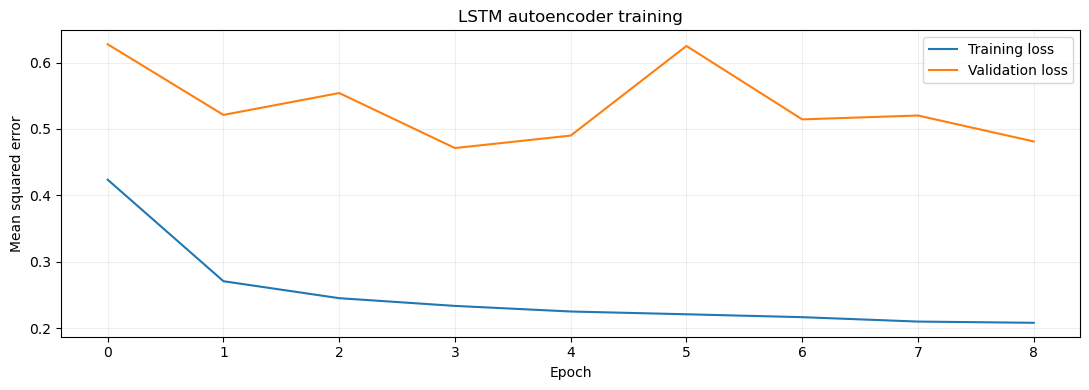

In [ ]:
autoencoder = LSTMAutoencoder(
    input_dim=train_data.shape[1],
    hidden_dim=AE_HIDDEN,
    latent_dim=AE_LATENT,
)
autoencoder, ae_train_losses, ae_validation_losses, ae_best_epoch = train_autoencoder(
    autoencoder, fit_windows, calibration_windows, AE_DEVICE
)
print("Best epoch (starting from 1):", ae_best_epoch + 1)

plt.plot(ae_train_losses, label="Training loss")
plt.plot(ae_validation_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("LSTM autoencoder training")
plt.legend()
plt.tight_layout()
plt.show()
del fit_windows, calibration_windows

In [ ]:
def reconstruction_residual_windows(model, windows, batch_size, device):
    loader = DataLoader(
        TensorDataset(torch.as_tensor(windows)),
        batch_size=batch_size,
        shuffle=False,
    )
    model.eval()
    residual_batches = []
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            reconstruction = model(batch)
            residual_batches.append(torch.abs(batch - reconstruction).cpu().numpy())
    return np.concatenate(residual_batches, axis=0)


def sequence_reconstruction_residuals(model, values, window, batch_size, device):
    windows, starts = make_windows(values, window)
    residual_windows = reconstruction_residual_windows(
        model, windows, batch_size, device
    )
    return average_overlapping_windows(
        residual_windows, starts, sequence_length=len(values)
    )


ae_train_residuals = sequence_reconstruction_residuals(
    autoencoder, train_scaled, AE_WINDOW, AE_BATCH_SIZE, AE_DEVICE
)
ae_test_residuals = sequence_reconstruction_residuals(
    autoencoder, test_scaled, AE_WINDOW, AE_BATCH_SIZE, AE_DEVICE
)
print("Autoencoder train residuals:", ae_train_residuals.shape)
print("Autoencoder test residuals: ", ae_test_residuals.shape)

Autoencoder train residuals: (28479, 38)
Autoencoder test residuals:  (28479, 38)


## Part 5: TiReX Zero-Shot Forecasting

TiReX is a pretrained time-series foundation model. In this experiment, I use it in a zero-shot setting, which means that it is not trained or fine-tuned on the SMD dataset. Since the public TiReX forecasting interface is applied to univariate context windows, I forecast each of the 38 SMD channels independently.

For each channel, TiReX predicts a future window from a past context window. I use the returned mean forecast and compare it with the true future values. The absolute forecast error is used as the raw residual signal: a larger error means that the observed behavior was harder for TiReX to predict. These residuals are then converted into anomaly scores in the following scoring step.


In [ ]:
try:
    from tirex import load_model
except ImportError as exc:
    raise ImportError(
        "Install TiReX with: pip install tirex-ts==1.4.2"
    ) from exc

print("Loading NX-AI/TiRex...")
tirex_model = load_model(
    "NX-AI/TiRex",
    device=TIREX_DEVICE,
    backend="torch",
)
print("TiReX loaded. No SMD fine-tuning will be performed.")

Loading NX-AI/TiRex...


TiReX loaded. No SMD fine-tuning will be performed.


In [ ]:
import numpy as np


def make_forecast_windows(values, context_length, horizon, stride):
    """Create past/future windows and future start timestamps."""
    if min(context_length, horizon, stride) <= 0:
        raise ValueError("context_length, horizon, and stride must be positive")
    last_start = len(values) - context_length - horizon
    if last_start < 0:
        raise ValueError("context_length + horizon is longer than the sequence")
    starts = np.arange(0, last_start + 1, stride, dtype=np.int64)
    if starts[-1] != last_start:
        starts = np.append(starts, last_start)
    past = np.stack([values[start:start + context_length] for start in starts])
    future = np.stack([
        values[start + context_length:start + context_length + horizon]
        for start in starts
    ])
    target_starts = starts + context_length
    return past.astype(np.float32), future.astype(np.float32), target_starts

In [ ]:
def to_numpy(values):
    if hasattr(values, "detach"):
        values = values.detach()
    if hasattr(values, "cpu"):
        values = values.cpu()
    if hasattr(values, "numpy"):
        values = values.numpy()
    return np.asarray(values, dtype=np.float64)


def tirex_sequence_residuals(
    model, values, context_length, horizon, stride, batch_size, label
):
    past, future, target_starts = make_forecast_windows(
        values, context_length, horizon, stride
    )
    n_windows, _, n_channels = past.shape
    flat_past = past.transpose(0, 2, 1).reshape(-1, context_length)
    flat_future = future.transpose(0, 2, 1).reshape(-1, horizon)
    residual_batches = []
    n_batches = math.ceil(len(flat_past) / batch_size)
    if hasattr(model, "eval"):
        model.eval()

    with torch.no_grad():
        for batch_number, start in enumerate(
            range(0, len(flat_past), batch_size), start=1
        ):
            stop = start + batch_size
            batch = torch.as_tensor(flat_past[start:stop], dtype=torch.float32)
            _, mean_forecast = model.forecast(batch, prediction_length=horizon)
            prediction = to_numpy(mean_forecast)
            residual_batches.append(np.abs(flat_future[start:stop] - prediction))
            print(f"{label} TiReX batch {batch_number}/{n_batches}", flush=True)

    flat_residuals = np.concatenate(residual_batches, axis=0)
    residual_windows = flat_residuals.reshape(n_windows, n_channels, horizon)
    residual_windows = residual_windows.transpose(0, 2, 1)
    return average_overlapping_windows(
        residual_windows, target_starts, sequence_length=len(values)
    )

In [ ]:
tirex_train_start = max(0, fit_end - TIREX_CONTEXT)
tirex_train_tail_residuals = tirex_sequence_residuals(
    tirex_model,
    train_scaled[tirex_train_start:],
    TIREX_CONTEXT,
    TIREX_HORIZON,
    TIREX_STRIDE,
    TIREX_BATCH_SIZE,
    label="Training",
)
tirex_train_residuals = np.full_like(train_scaled, np.nan, dtype=np.float64)
tirex_train_residuals[tirex_train_start:] = tirex_train_tail_residuals

tirex_test_residuals = tirex_sequence_residuals(
    tirex_model,
    test_scaled,
    TIREX_CONTEXT,
    TIREX_HORIZON,
    TIREX_STRIDE,
    TIREX_BATCH_SIZE,
    label="Test",
)
print("TiReX train residuals:", tirex_train_residuals.shape)
print("TiReX test residuals: ", tirex_test_residuals.shape)
print(
    "Valid TiReX test timestamps:",
    int(np.isfinite(tirex_test_residuals).all(axis=1).sum()),
)

Training TiReX batch 1/7


Training TiReX batch 2/7


Training TiReX batch 3/7


Training TiReX batch 4/7


Training TiReX batch 5/7


...

Test TiReX batch 19/22


Test TiReX batch 20/22


Test TiReX batch 21/22


Test TiReX batch 22/22


TiReX train residuals: (28479, 38)
TiReX test residuals:  (28479, 38)
Valid TiReX test timestamps: 28383


## Part 6: Shared Anomaly Scoring

The two models produce different types of residuals, but after residual construction they have the same shape: timestamps by 38 channels.

For a controlled comparison, both models use the same postprocessing procedure:

1. estimate a typical residual size for each channel on the normal calibration split;
2. divide each channel residual by its own scale;
3. average the five largest scaled channel residuals at each timestamp;
4. set the threshold to the 99.5th percentile of scores from the normal threshold split.

The scoring rule is shared across both methods, but each model has its own channel scales and threshold because the raw residual values are different.

In [ ]:
import numpy as np


def robust_channel_scale(residuals, epsilon=1e-8):
    """Estimate one robust normal residual scale per channel."""
    residuals = np.asarray(residuals, dtype=np.float64)
    scale = np.nanmedian(np.abs(residuals), axis=0)
    fallback = np.nanmean(np.abs(residuals), axis=0)
    scale = np.where(np.isfinite(scale) & (scale > epsilon), scale, fallback)
    return np.where(np.isfinite(scale) & (scale > epsilon), scale, 1.0)


def make_anomaly_scores(residuals, channel_scale, top_k=5):
    """Average the largest standardized channel residuals per timestamp."""
    standardized = np.asarray(residuals, dtype=np.float64) / channel_scale
    if not 1 <= top_k <= standardized.shape[1]:
        raise ValueError("top_k must be between 1 and the channel count")
    scores = np.full(len(standardized), np.nan, dtype=np.float64)
    valid = np.isfinite(standardized).all(axis=1)
    largest = np.partition(standardized[valid], -top_k, axis=1)[:, -top_k:]
    scores[valid] = largest.mean(axis=1)
    return scores


def fit_score_pipeline(train_residuals, test_residuals):
    channel_scale = robust_channel_scale(train_residuals[calibration_slice])
    train_scores = make_anomaly_scores(train_residuals, channel_scale, TOP_K)
    test_scores = make_anomaly_scores(test_residuals, channel_scale, TOP_K)
    normal_scores = train_scores[threshold_slice]
    normal_scores = normal_scores[np.isfinite(normal_scores)]
    if len(normal_scores) == 0:
        raise ValueError("No finite normal scores are available for threshold fitting")
    threshold = float(np.quantile(normal_scores, THRESHOLD_QUANTILE))
    return channel_scale, train_scores, test_scores, threshold

In [ ]:
(
    ae_channel_scale,
    ae_train_scores,
    ae_test_scores,
    ae_threshold,
) = fit_score_pipeline(ae_train_residuals, ae_test_residuals)
(
    tirex_channel_scale,
    tirex_train_scores,
    tirex_test_scores,
    tirex_threshold,
) = fit_score_pipeline(tirex_train_residuals, tirex_test_residuals)

print(f"Autoencoder threshold: {ae_threshold:.6f}")
print(f"TiReX threshold:       {tirex_threshold:.6f}")

Autoencoder threshold: 10.330859
TiReX threshold:       70.121097


### Label Use and Thresholding

Test labels are kept out of preprocessing, model fitting, residual scaling, score construction, and threshold selection. They are used only for label-aware dataset inspection in Part 2 and for metric calculation in Part 7. This keeps the detector comparison unsupervised even though the dataset provides labels for evaluation.

## Part 7: Evaluation

Final metrics are calculated with the official test labels. Because the two methods have different temporal coverage, metrics are calculated only where both score arrays are finite.

In [ ]:
def evaluate_model(labels, scores, threshold, valid_mask):
    labels = np.asarray(labels, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float64)
    mask = valid_mask & np.isfinite(scores)
    if not mask.any():
        raise ValueError("No valid timestamps are available for evaluation")
    y_true = labels[mask]
    y_score = scores[mask]
    y_pred = (y_score > threshold).astype(np.int64)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return {
        "timestamps": int(mask.sum()),
        "anomalies": int(y_true.sum()),
        "threshold": float(threshold),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "pr_auc": float(average_precision_score(y_true, y_score)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
    }

In [ ]:
common_mask = np.isfinite(ae_test_scores) & np.isfinite(tirex_test_scores)
metrics = {
    "LSTM autoencoder": evaluate_model(
        test_labels, ae_test_scores, ae_threshold, common_mask
    ),
    "TiReX zero-shot": evaluate_model(
        test_labels, tirex_test_scores, tirex_threshold, common_mask
    ),
}
metrics_df = pd.DataFrame(metrics).T
print("Shared evaluation timestamps:", int(common_mask.sum()))
display(metrics_df.round(4))

Shared evaluation timestamps: 28383


,timestamps,anomalies,threshold,precision,recall,f1,pr_auc,roc_auc
LSTM autoencoder,28383.0,2694.0,10.3309,0.2380,0.9762,0.3827,0.5975,0.9170
TiReX zero-shot,28383.0,2694.0,70.1211,0.3373,0.3352,0.3363,0.2898,0.7287


## Part 8: Visual Comparison

The score traces show when each detector crosses its threshold. Precision-recall and ROC curves evaluate score ranking without fixing one threshold.

The score trace uses log1p only for visualization because a few extreme residuals would otherwise hide the thresholds. All metrics still use the original scores.

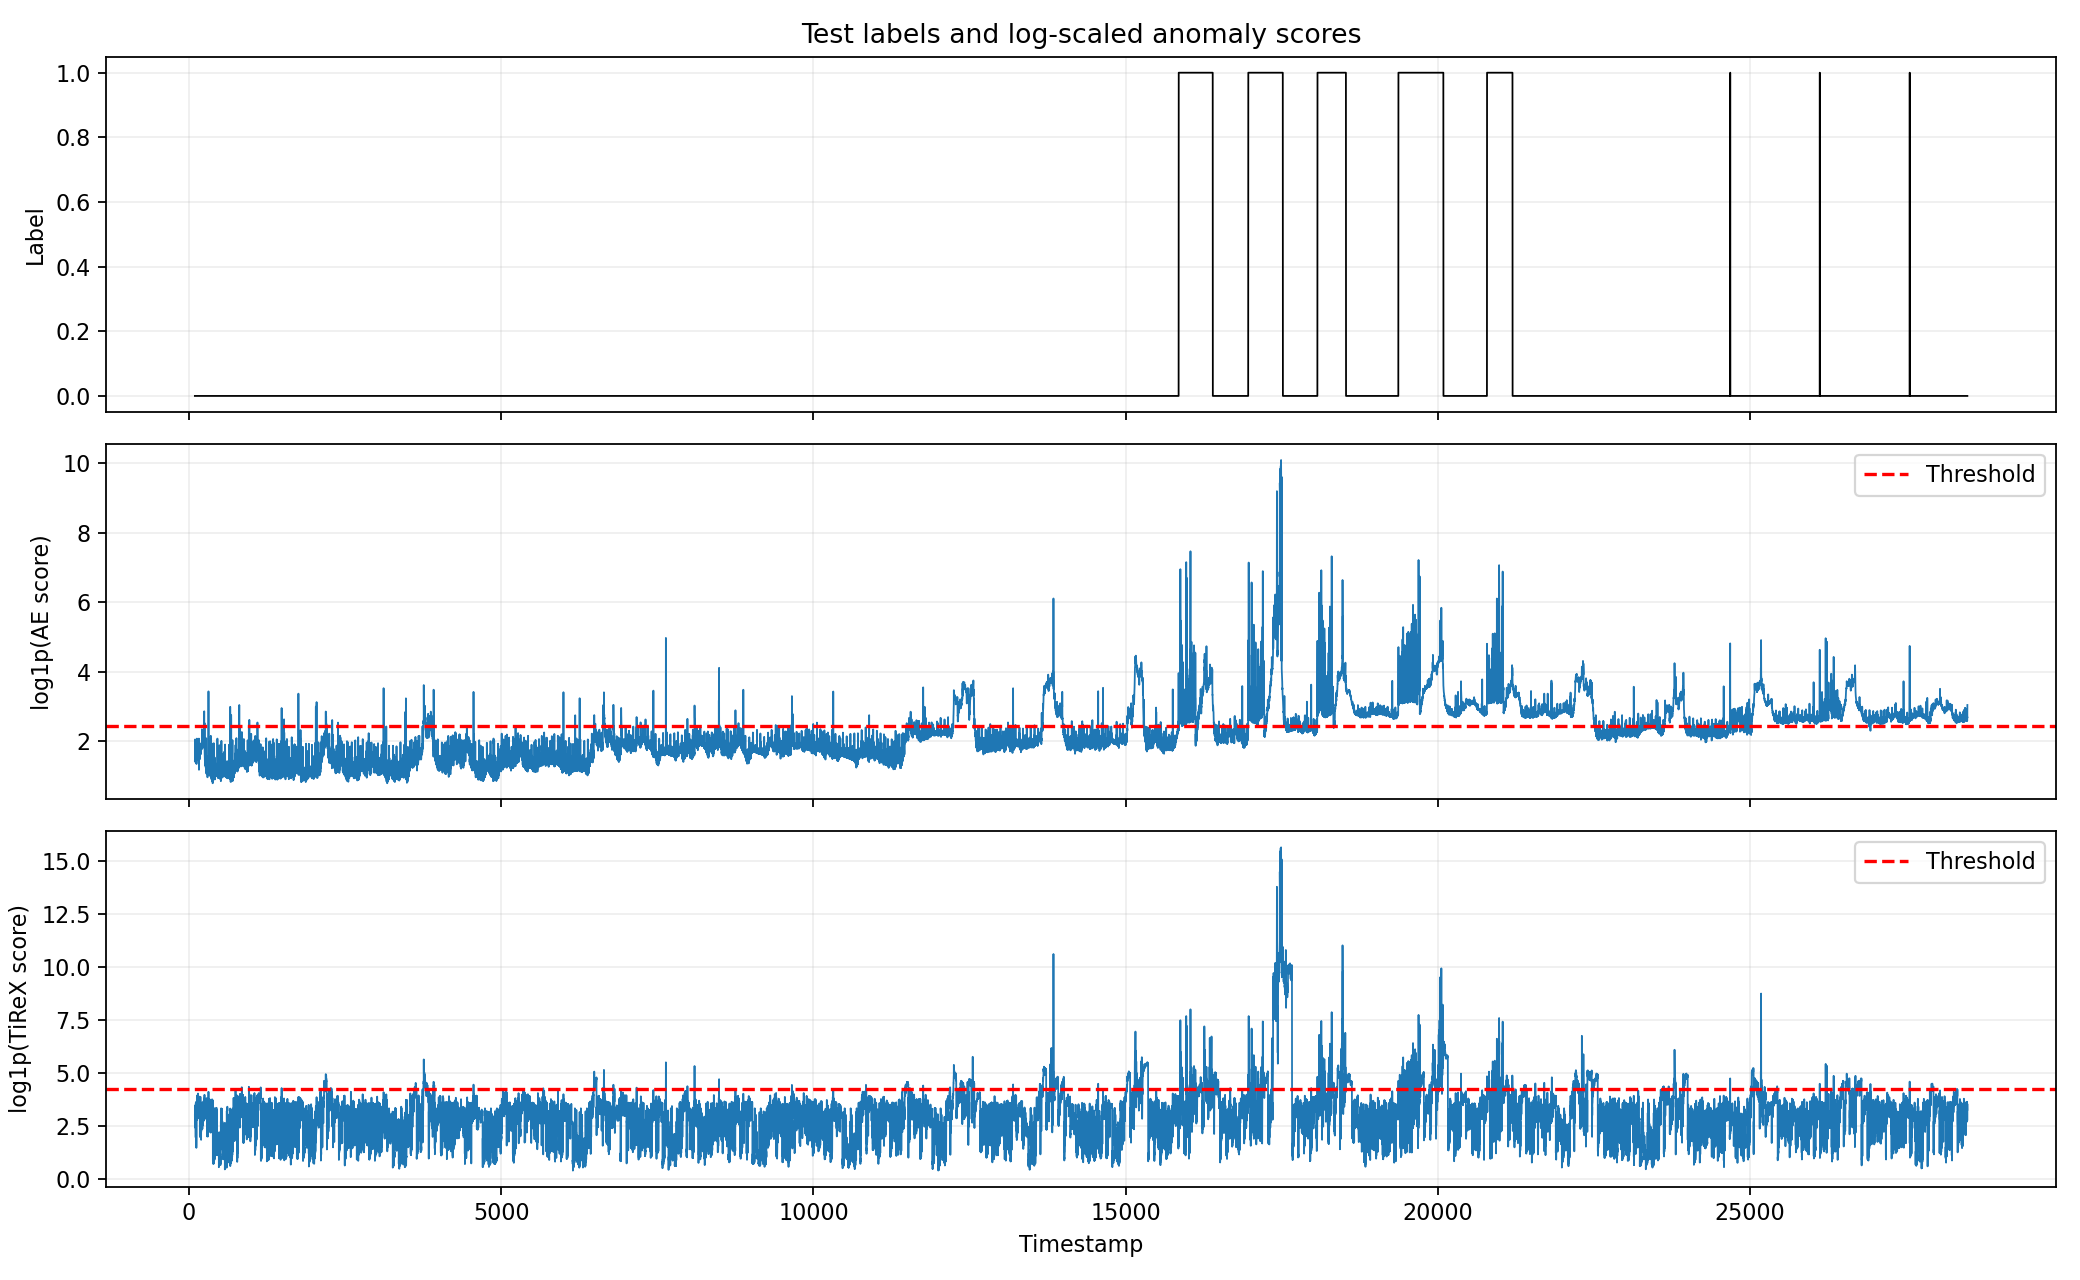

In [ ]:
valid_indices = np.flatnonzero(common_mask)
score_figure, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(valid_indices, test_labels[common_mask], color="black", linewidth=0.8)
axes[0].set_ylabel("Label")
axes[0].set_title("Test labels and log-scaled anomaly scores")
axes[1].plot(valid_indices, np.log1p(ae_test_scores[common_mask]), linewidth=0.8)
axes[1].axhline(np.log1p(ae_threshold), color="red", linestyle="--", label="Threshold")
axes[1].set_ylabel("log1p(AE score)")
axes[1].legend()
axes[2].plot(valid_indices, np.log1p(tirex_test_scores[common_mask]), linewidth=0.8)
axes[2].axhline(np.log1p(tirex_threshold), color="red", linestyle="--", label="Threshold")
axes[2].set_ylabel("log1p(TiReX score)")
axes[2].set_xlabel("Timestamp")
axes[2].legend()
score_figure.tight_layout()
plt.show()

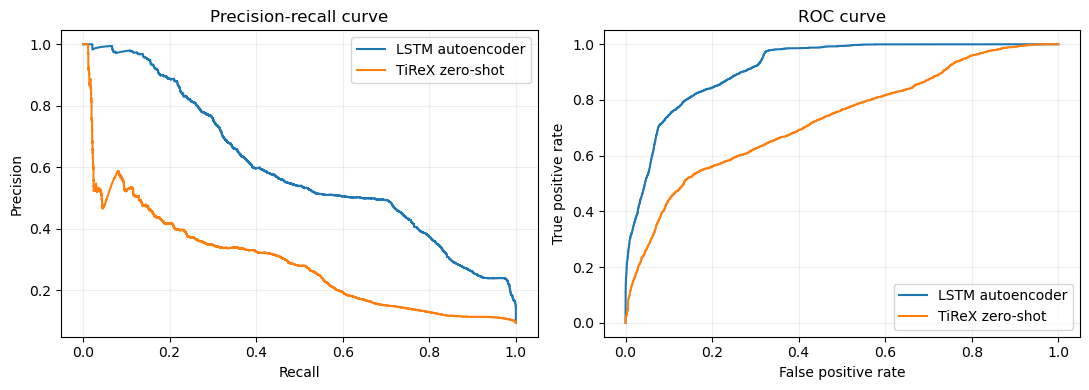

In [ ]:
y_true = test_labels[common_mask]
score_arrays = {
    "LSTM autoencoder": ae_test_scores[common_mask],
    "TiReX zero-shot": tirex_test_scores[common_mask],
}
ranking_figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for model_name, model_scores in score_arrays.items():
    precision, recall, _ = precision_recall_curve(y_true, model_scores)
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true, model_scores)
    axes[0].plot(recall, precision, label=model_name)
    axes[1].plot(false_positive_rate, true_positive_rate, label=model_name)
axes[0].set_title("Precision-recall curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[1].set_title("ROC curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
for axis in axes:
    axis.legend()
ranking_figure.tight_layout()
plt.show()

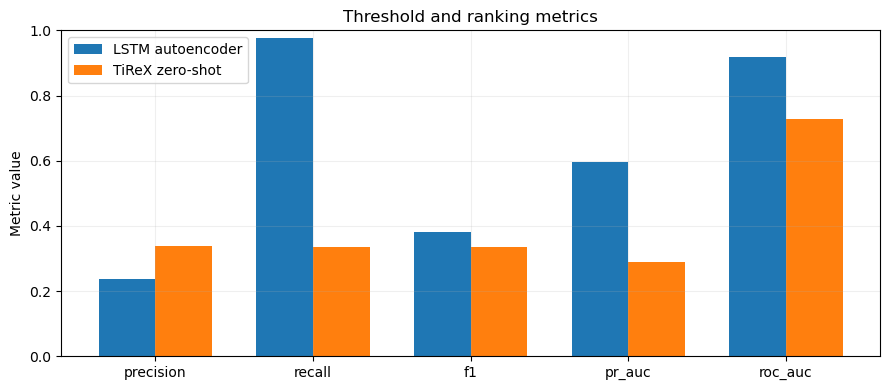

In [ ]:
metric_names = ["precision", "recall", "f1", "pr_auc", "roc_auc"]
metric_figure, axis = plt.subplots(figsize=(9, 4))
positions = np.arange(len(metric_names))
width = 0.36
for model_index, model_name in enumerate(metrics_df.index):
    values = metrics_df.loc[model_name, metric_names].astype(float).to_numpy()
    axis.bar(
        positions + (model_index - 0.5) * width,
        values,
        width,
        label=model_name,
    )
axis.set_xticks(positions, metric_names)
axis.set_ylim(0, 1)
axis.set_ylabel("Metric value")
axis.set_title("Threshold and ranking metrics")
axis.legend()
metric_figure.tight_layout()
plt.show()

## Part 9: Save Results and Conclusion

The TiReX run is expensive, so the final cell saves the model, residuals, scores, metrics, and figures. The saved arrays can be inspected later without rerunning the complete notebook.

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(autoencoder.state_dict(), OUTPUT_DIR / "autoencoder_model.pt")
np.savez_compressed(
    OUTPUT_DIR / "outputs.npz",
    ae_train_residuals=ae_train_residuals,
    ae_test_residuals=ae_test_residuals,
    tirex_train_residuals=tirex_train_residuals,
    tirex_test_residuals=tirex_test_residuals,
    ae_train_scores=ae_train_scores,
    ae_test_scores=ae_test_scores,
    tirex_train_scores=tirex_train_scores,
    tirex_test_scores=tirex_test_scores,
    labels=test_labels,
    ae_channel_scale=ae_channel_scale,
    tirex_channel_scale=tirex_channel_scale,
    ae_threshold=np.array(ae_threshold),
    tirex_threshold=np.array(tirex_threshold),
    feature_mean=feature_mean,
    feature_std=feature_std,
    common_mask=common_mask,
)
metrics_df.to_csv(OUTPUT_DIR / "metrics.csv")
with (OUTPUT_DIR / "metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)
    handle.write("\n")
score_figure.savefig(OUTPUT_DIR / "score_comparison.png", dpi=160)
ranking_figure.savefig(OUTPUT_DIR / "ranking_curves.png", dpi=160)
metric_figure.savefig(OUTPUT_DIR / "metric_comparison.png", dpi=160)

display_output_dir = OUTPUT_DIR.relative_to(PROJECT_ROOT)
print("Saved results to:", display_output_dir)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)

Saved results to: results/notebook_complete
 - autoencoder_model.pt
 - metric_comparison.png
 - metrics.csv
 - metrics.json
 - outputs.npz
 - ranking_curves.png
 - score_comparison.png


In [ ]:
for metric_name in ["f1", "pr_auc", "roc_auc"]:
    winner = metrics_df[metric_name].astype(float).idxmax()
    value = float(metrics_df.loc[winner, metric_name])
    print(f"Best {metric_name}: {winner} ({value:.4f})")

print(
    "\nConclusion: these results describe one SMD machine only. "
    "They should not be treated as proof that one method is always better "
    "for every server or anomaly type."
)

Best f1: LSTM autoencoder (0.3827)
Best pr_auc: LSTM autoencoder (0.5975)
Best roc_auc: LSTM autoencoder (0.9170)

Conclusion: these results describe one SMD machine only. They should not be treated as proof that one method is always better for every server or anomaly type.


### Note about threshold selection and possible extension

One possible mistake is to choose the threshold by looking at the test labels. I avoided this because the test labels should only be used for checking the final result, not for choosing the threshold. Otherwise, the result would be too optimistic and not a real unsupervised evaluation.
As a possible extension, this notebook could also be tested on another SMD machine by changing the machine name. I did not include this in the main experiment because the current work focuses on one selected machine.
